# 05 - Random Forest

Ensemble de árvores de decisão. Espera-se maior capacidade de capturar interações não-lineares entre via, clima e veículo do que a Regressão Logística, ao custo de menor interpretabilidade direta e maior tempo de treino.

## 1. Importações

In [1]:
import sys
sys.path.append('../src')

import time
import json
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score
)

from preparar_dados import carregar_dados

import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas importadas com sucesso!")


✅ Bibliotecas importadas com sucesso!


## 2. Carregamento e Preparação dos Dados

In [2]:
X_train, X_test, y_train, y_test = carregar_dados()

print(f"Registros de treino: {X_train.shape[0]} | Registros de teste: {X_test.shape[0]}")
print(f"Total de features após encoding: {X_train.shape[1]}")


Registros de treino: 152012 | Registros de teste: 64722
Total de features após encoding: 77


## 3. Treinamento do Random Forest

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Nenhuma versão anterior deste notebook tunava hiperparâmetros - usava só os valores
# default do sklearn/xgboost/lightgbm. RandomizedSearchCV otimizando average_precision
# (PR-AUC) em vez de accuracy/AUC, porque é a métrica mais informativa em datasets
# desbalanceados (~13% de casos graves/fatais). cv=3 é StratifiedKFold simples (não
# respeita agrupamento por acidente dentro do CV - só o split treino/teste externo é
# agrupado); para eliminar esse resíduo, seria necessário propagar os grupos também
# para dentro da busca (GroupKFold), fica como próximo passo se necessário.

espaco_busca = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
}

base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1)

busca = RandomizedSearchCV(
    base, espaco_busca, n_iter=10, scoring='average_precision',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, verbose=1,
)

tempo_inicio = time.time()
busca.fit(X_train, y_train)
tempo_treino = time.time() - tempo_inicio

modelo = busca.best_estimator_
print(f"✅ Random Forest (tunado) treinado em {tempo_treino:.3f} segundos!")
print(f"Melhores hiperparâmetros: {busca.best_params_}")
print(f"Melhor average_precision (CV): {busca.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


✅ Random Forest (tunado) treinado em 294.402 segundos!
Melhores hiperparâmetros: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}
Melhor average_precision (CV): 0.4415


## 4. Avaliação do Modelo

Limiar de decisão calibrado para recall >= 75%: 0.3899
--- RELATÓRIO DE CLASSIFICAÇÃO: Random Forest ---
                     precision    recall  f1-score   support

0: Leve/Sem Vítimas       0.95      0.68      0.79     56293
     1: Grave/Fatal       0.26      0.75      0.38      8429

           accuracy                           0.69     64722
          macro avg       0.60      0.71      0.59     64722
       weighted avg       0.86      0.69      0.74     64722



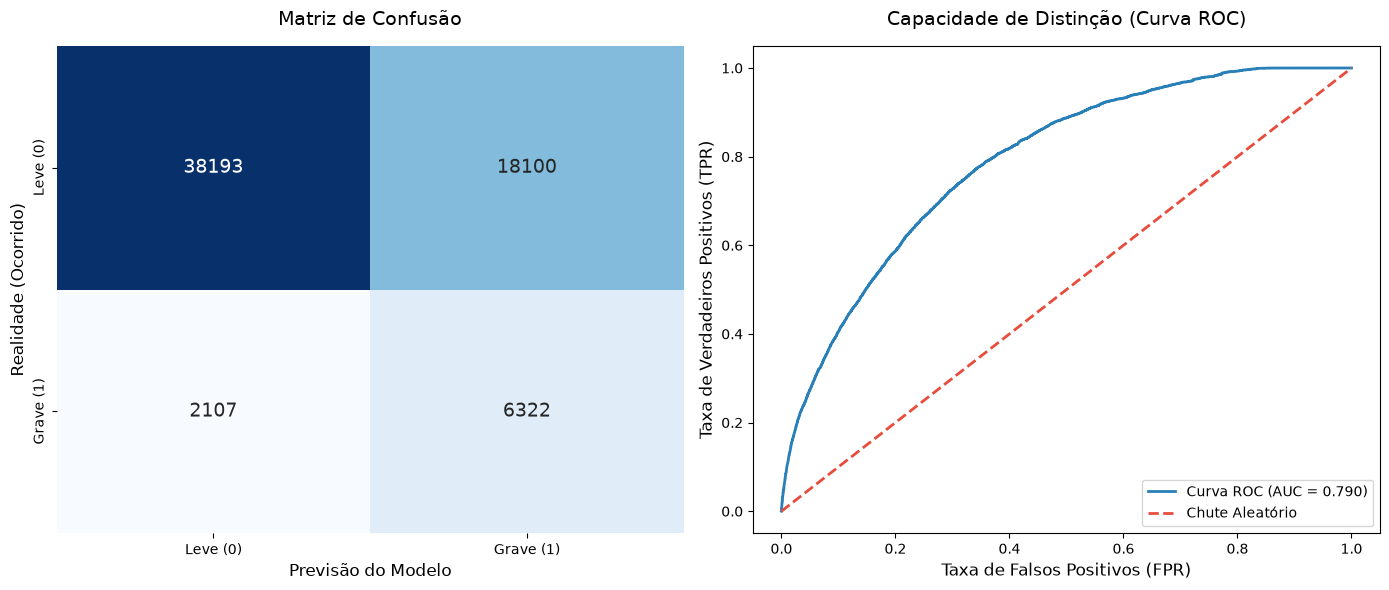

Acurácia: 0.6878 | Precision: 0.2589 | Recall: 0.7500 | AUC: 0.7897


In [4]:
from sklearn.metrics import precision_recall_curve

# Threshold calibrado por modelo (em vez de um valor fixo de 0.5 ou 0.25): modelos com
# class_weight='balanced'/scale_pos_weight já deslocam a probabilidade prevista de forma
# diferente entre si, então um corte fixo produz operações muito desiguais (ex.: um mesmo
# 0.25 pode gerar 76% de recall num modelo e 96% - com precisão < 20% - em outro). Aqui
# buscamos, para CADA modelo, o limiar que atinge pelo menos RECALL_ALVO de recall na
# classe grave/fatal, priorizando não perder casos reais, mas escolhendo entre os limiares
# válidos aquele que preserva a maior precisão possível (menos falso alarme).
RECALL_ALVO = 0.75

y_prob = modelo.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

candidatos = recalls[:-1] >= RECALL_ALVO
if candidatos.any():
    LIMIAR_DECISAO = thresholds[candidatos][np.argmax(precisions[:-1][candidatos])]
else:
    LIMIAR_DECISAO = thresholds[np.argmax(recalls[:-1])]

y_pred = (y_prob >= LIMIAR_DECISAO).astype(int)
print(f"Limiar de decisão calibrado para recall >= {RECALL_ALVO:.0%}: {LIMIAR_DECISAO:.4f}")

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("--- RELATÓRIO DE CLASSIFICAÇÃO: Random Forest ---")
print(classification_report(y_test, y_pred, target_names=['0: Leve/Sem Vítimas', '1: Grave/Fatal']))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

matriz = confusion_matrix(y_test, y_pred)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Leve (0)', 'Grave (1)'],
            yticklabels=['Leve (0)', 'Grave (1)'],
            cbar=False, annot_kws={"size": 14})
axes[0].set_title('Matriz de Confusão', fontsize=14, pad=15)
axes[0].set_xlabel('Previsão do Modelo', fontsize=12)
axes[0].set_ylabel('Realidade (Ocorrido)', fontsize=12)

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#2980b9', lw=2, label=f'Curva ROC (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='#e74c3c', lw=2, linestyle='--', label='Chute Aleatório')
axes[1].set_title('Capacidade de Distinção (Curva ROC)', fontsize=14, pad=15)
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print(f"Acurácia: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | AUC: {auc:.4f}")


## 5. Importância das Variáveis

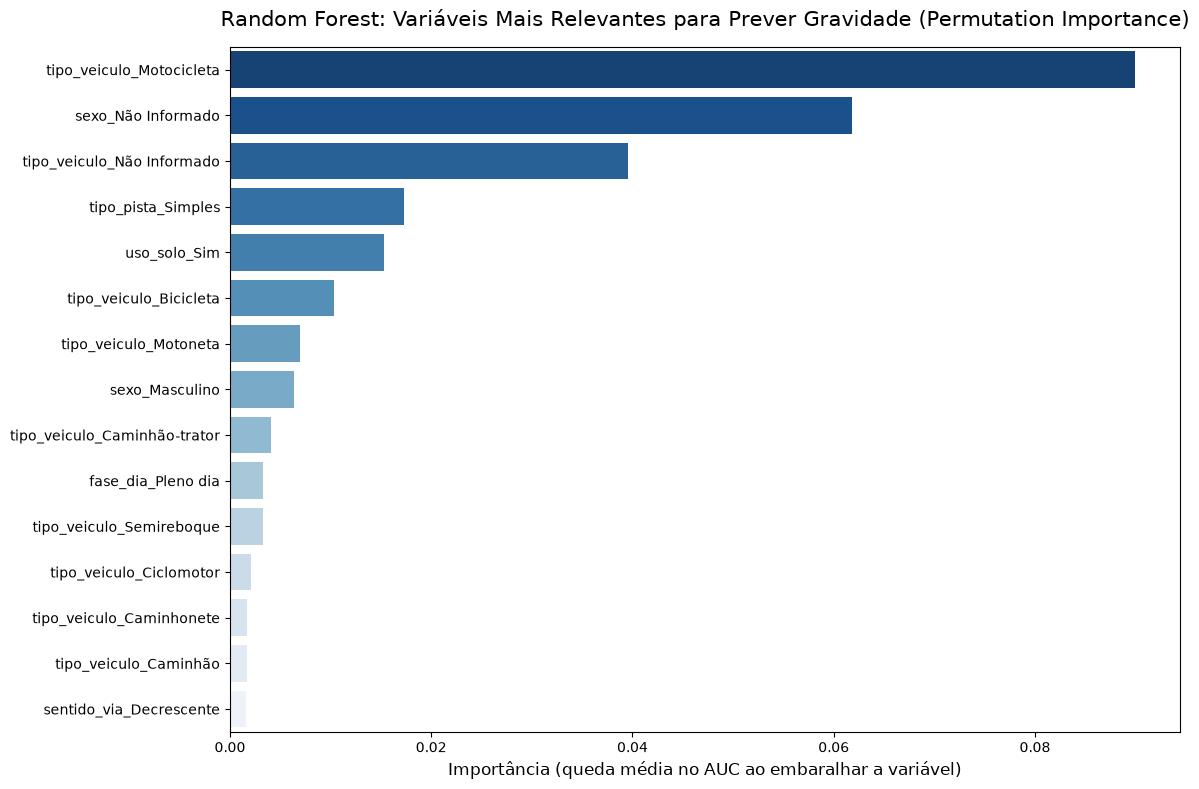

In [5]:
from sklearn.inspection import permutation_importance

# Gini/MDI (.feature_importances_) superestima variáveis contínuas e de alta cardinalidade
# (ex.: icm/icc/icp têm correlação de Pearson ~0 com o alvo mas apareciam no topo do ranking Gini
# nesse dataset). Permutation importance mede a queda real de AUC ao embaralhar cada variável -
# mais confiável para decidir quais features realmente importam.
amostra_idx = X_test.sample(n=min(8000, len(X_test)), random_state=42).index
resultado_perm = permutation_importance(
    modelo, X_test.loc[amostra_idx], y_test.loc[amostra_idx],
    n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=-1
)

importancias = pd.DataFrame({
    'Variavel': X_train.columns,
    'Importancia': resultado_perm.importances_mean
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importancias.head(15), x='Importancia', y='Variavel', palette='Blues_r')
plt.title('Random Forest: Variáveis Mais Relevantes para Prever Gravidade (Permutation Importance)', fontsize=15, pad=15)
plt.xlabel('Importância (queda média no AUC ao embaralhar a variável)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

## 5.1. Por que "Não Informado" aparece entre as variáveis mais relevantes?

`sexo_Não Informado` e `tipo_veiculo_Não Informado` aparecem entre as variáveis mais relevantes do modelo. Em vez de descartar isso como ruído (ou remover essas linhas da base), investigamos a que esse sinal se refere.

In [6]:
# Diagnóstico: por que sexo_Não Informado e tipo_veiculo_Não Informado pesam tanto?
taxa_geral = y_train.mean() * 100
print(f"Taxa geral de severidade (treino): {taxa_geral:.2f}%\n")

for col in ['sexo_Não Informado', 'tipo_veiculo_Não Informado']:
    if col in X_train.columns:
        mask = X_train[col] == 1
        taxa_sub = y_train[mask].mean() * 100
        print(f"{col}: {mask.sum()} registros ({mask.mean()*100:.1f}% da base de treino) "
              f"| taxa de severidade = {taxa_sub:.2f}%")

# Hipótese: sexo Não Informado se concentra em veículos sem condutor próprio (reboques/semirreboques)
if 'sexo_Não Informado' in X_train.columns:
    cols_veiculo = [c for c in X_train.columns if c.startswith('tipo_veiculo_')]
    print("\nTipos de veículo mais frequentes quando sexo = Não Informado:")
    print(X_train.loc[X_train['sexo_Não Informado'] == 1, cols_veiculo].sum().sort_values(ascending=False).head(5))

print(
    "\nInterpretação: 'sexo_Não Informado' concentra-se em registros de reboque/semirreboque "
    "(veículo sem condutor próprio) - por isso a taxa de severidade nesse grupo tende a zero: "
    "não é que 'sexo desconhecido' proteja contra acidente grave, é que esse registro descreve "
    "o veículo, não uma pessoa ferida (artefato da granularidade por pessoa/veículo-envolvido "
    "do dataset). Já 'tipo_veiculo_Não Informado' tem taxa de severidade ACIMA da média - "
    "plausivelmente porque acidentes mais graves (destruição do veículo, fuga, múltiplos "
    "envolvidos) dificultam o preenchimento correto do formulário PRF. Mantemos essas colunas "
    "no modelo (não removemos as linhas), mas é importante que o time saiba que parte dessa "
    "importância reflete o PROCESSO de registro do acidente, não um fator de risco da via em si."
)

Taxa geral de severidade (treino): 12.96%

sexo_Não Informado: 22353 registros (14.7% da base de treino) | taxa de severidade = 0.00%
tipo_veiculo_Não Informado: 5037 registros (3.3% da base de treino) | taxa de severidade = 34.37%

Tipos de veículo mais frequentes quando sexo = Não Informado:
tipo_veiculo_Semireboque      11628
tipo_veiculo_Não Informado     2304
tipo_veiculo_Reboque           1150
tipo_veiculo_Caminhão          1012
tipo_veiculo_Motocicleta        952
dtype: int64

Interpretação: 'sexo_Não Informado' concentra-se em registros de reboque/semirreboque (veículo sem condutor próprio) - por isso a taxa de severidade nesse grupo tende a zero: não é que 'sexo desconhecido' proteja contra acidente grave, é que esse registro descreve o veículo, não uma pessoa ferida (artefato da granularidade por pessoa/veículo-envolvido do dataset). Já 'tipo_veiculo_Não Informado' tem taxa de severidade ACIMA da média - plausivelmente porque acidentes mais graves (destruição do veículo, fuga

## 6. Exportação do Modelo e das Métricas

In [7]:
os.makedirs('../models', exist_ok=True)

joblib.dump(modelo, '../models/modelo_random_forest.pkl')
joblib.dump(X_train.columns.tolist(), '../models/colunas_treino.pkl')

resultado = {
    'chave': 'random_forest',
    'algoritmo': 'Random Forest',
    'acuracia': round(float(acc), 4),
    'precision': round(float(prec), 4),
    'recall': round(float(rec), 4),
    'auc_score': round(float(auc), 4),
    'tempo_segundos': round(float(tempo_treino), 4),
}

with open('../models/resultados_random_forest.json', 'w', encoding='utf-8') as f:
    json.dump(resultado, f, ensure_ascii=False, indent=2)

print(f"✅ Modelo e métricas de Random Forest exportados com sucesso!")
resultado


✅ Modelo e métricas de Random Forest exportados com sucesso!


{'chave': 'random_forest',
 'algoritmo': 'Random Forest',
 'acuracia': 0.6878,
 'precision': 0.2589,
 'recall': 0.75,
 'auc_score': 0.7897,
 'tempo_segundos': 294.4022}